# Laboratorio: Aprendizaje Supervisado
## Regresión y Clasificación Binaria con scikit-learn

**Curso:** CC3085 – Inteligencia Artificial  

**Integrantes:**
- Diego Rosales - 23258
- Diego López - 23242


# Parte 1 — Problema de Regresión
**Dataset:** California Housing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 1. Carga y exploración de datos
### Carga del dataset

Las variables independientes (`X`) y la variable objetivo (`y`) se separan explícitamente
siguiendo el enfoque estándar de aprendizaje supervisado. Esto permite entrenar y evaluar
modelos de forma clara, ya que los algoritmos de `scikit-learn` esperan esta estructura
para el proceso de ajuste y predicción.

El DataFrame combinado se utiliza únicamente con fines de exploración y análisis
descriptivo.

In [2]:
# Cargar el dataset
housing = fetch_california_housing(as_frame=True)

# Variables independientes
X = housing.data
# Variable objetivo
y = housing.target

# Unir todo en un solo DataFrame para facilitar la exploración
df = pd.concat([X, y.rename("MedHouseValue")], axis=1)

# Mostrar las primeras filas
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Estadísticas descriptivas


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Distribución de la variable objetivo

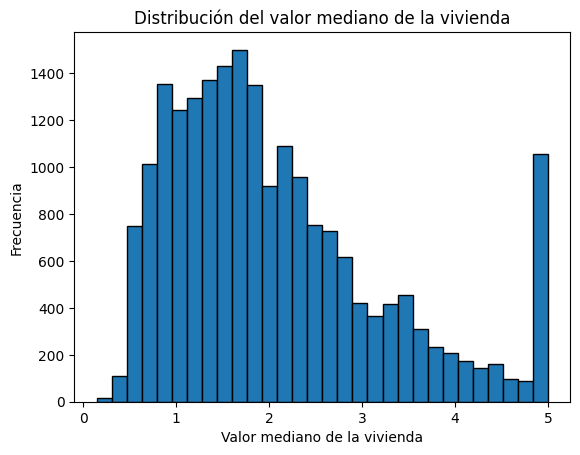

In [4]:
plt.hist(df["MedHouseValue"], bins=30, edgecolor="black")
plt.xlabel("Valor mediano de la vivienda")
plt.ylabel("Frecuencia")
plt.title("Distribución del valor mediano de la vivienda")
plt.show()

## 2. Separación de datos


La función `train_test_split` se utiliza para dividir el conjunto de datos en dos
subconjuntos: uno de entrenamiento y otro de prueba. El conjunto de entrenamiento
se emplea para ajustar los modelos, mientras que el conjunto de prueba se utiliza
para evaluar su desempeño sobre datos que el modelo no ha visto previamente.

Esta separación es fundamental en aprendizaje supervisado, ya que permite estimar
la capacidad de generalización del modelo y detectar posibles problemas de sobreajuste,
es decir, cuando un modelo aprende demasiado bien los datos de entrenamiento pero
tiene un mal desempeño en datos nuevos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras


Se utiliza un valor de `test_size = 0.2`, lo que corresponde a una división 80% para
entrenamiento y 20% para prueba. Esta proporción es ampliamente utilizada en la
práctica, ya que ofrece un buen balance entre disponer de suficientes datos para que
el modelo aprenda patrones relevantes y contar con un conjunto de prueba lo
suficientemente grande para evaluar su desempeño de manera confiable.

El parámetro `random_state` se fija con el valor 42 para controlar la aleatoriedad
del proceso de partición. El número 42 no tiene un significado estadístico especial,
sino que se utiliza por convención en la comunidad como un valor arbitrario pero
consistente. Fijar este valor garantiza que la división de los datos sea reproducible,
es decir, que al ejecutar el notebook múltiples veces se obtengan exactamente los
mismos subconjuntos de entrenamiento y prueba.

## 3. Entrenamiento inicial de modelos
En esta sección se entrenan distintos modelos de regresión utilizando sus
hiperparámetros por defecto. El objetivo es obtener una primera referencia
del desempeño de cada modelo antes de realizar cualquier proceso de
optimización.


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Métricas de evaluación

Para evaluar el desempeño de los modelos de regresión se utilizan las
siguientes métricas:

- **MAE (Mean Absolute Error):** mide el error promedio absoluto entre los
  valores reales y las predicciones.
- **RMSE (Root Mean Squared Error):** penaliza más fuertemente los errores
  grandes, ya que eleva las diferencias al cuadrado.
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad
  de la variable objetivo es explicada por el modelo.

In [7]:
def evaluar_regresion(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

### Regresión Lineal
Se entrena un modelo de Regresión Lineal como línea base, ya que es un modelo
simple que permite capturar relaciones lineales entre las variables
independientes y la variable objetivo.


In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr, rmse_lr, r2_lr = evaluar_regresion(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr

(0.5332001304956557, np.float64(0.7455813830127758), 0.5757877060324514)

### Árbol de Decisión para Regresión
El Árbol de Decisión es un modelo no lineal que divide el espacio de variables
en regiones, permitiendo capturar relaciones más complejas entre las
características.

In [9]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt, rmse_dt, r2_dt = evaluar_regresion(y_test, y_pred_dt)

mae_dt, rmse_dt, r2_dt

(0.45467918846899225, np.float64(0.7037294974840077), 0.622075845135081)

### Random Forest para Regresión
Random Forest es un modelo de conjunto que combina múltiples árboles de
decisión entrenados sobre diferentes subconjuntos de los datos, lo que
permite mejorar la capacidad de generalización y reducir el sobreajuste.

In [10]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluar_regresion(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(0.32754256845930246, np.float64(0.5053399773665033), 0.8051230593157366)

### Comparación de resultados iniciales

A continuación, se comparan los resultados obtenidos por cada modelo utilizando
sus hiperparámetros por defecto, evaluados sobre el conjunto de prueba.

In [11]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Random Forest"],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "R2": [r2_lr, r2_dt, r2_rf]
})

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.533200,0.745581,0.575788
1,Árbol de Decisión,0.454679,0.703729,0.622076
2,Random Forest,0.327543,0.505340,0.805123


## 4. Optimizacion de hiperparametros

Se optimizan hiperparametros de los modelos basados en arboles para mejorar el rendimiento
y reducir el sobreajuste. Se usa validacion cruzada con `cv=5` para obtener una estimacion
robusta del desempeno.

### Eleccion del metodo de busqueda

- **Arbol de Decision:** Se utiliza `GridSearchCV` porque el espacio de busqueda es pequeno y
  permite evaluar todas las combinaciones posibles.
- **Random Forest:** Se utiliza `RandomizedSearchCV` porque el espacio de busqueda es amplio y
  cada evaluacion es costosa; `n_iter=20` ofrece un buen equilibrio entre calidad y tiempo.

**Justificacion de la metrica:** se optimiza `neg_mean_squared_error` porque penaliza mas los
errores grandes y es consistente con RMSE, una metrica principal en regresion.

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Optimizacion del Arbol de Decision

**Justificacion de los espacios de busqueda:**

- `max_depth`: compara arboles sin poda vs. arboles acotados para controlar complejidad.
- `min_samples_leaf`: evita hojas con muy pocos ejemplos y mejora generalizacion.
- `min_samples_split`: impide divisiones poco informativas en nodos pequenos.

In [13]:
param_grid_dt = {
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

In [14]:
dt_gs = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

dt_gs.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [15]:
dt_gs.best_params_


{'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}

In [16]:
best_dt = dt_gs.best_estimator_

y_pred_dt_opt = best_dt.predict(X_test)
mae_dt_opt, rmse_dt_opt, r2_dt_opt = evaluar_regresion(y_test, y_pred_dt_opt)

mae_dt_opt, rmse_dt_opt, r2_dt_opt


(0.4041270341593175, np.float64(0.59777745113437), 0.7273081251592183)

### Optimizacion de Random Forest

**Justificacion de los espacios de busqueda:**

- `n_estimators`: mas arboles suelen reducir la varianza (100-500 equilibra costo y estabilidad).
- `max_depth` y `min_samples_leaf`: regulan el sobreajuste y suavizan la particion.
- `max_features`: `sqrt` y `log2` decorrelacionan arboles y mejoran generalizacion.

In [17]:
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}


In [18]:
rf_rs = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42
)

rf_rs.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [19]:
rf_rs.best_params_


{'n_estimators': 200,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30}

In [20]:
best_rf = rf_rs.best_estimator_

y_pred_rf_opt = best_rf.predict(X_test)
mae_rf_opt, rmse_rf_opt, r2_rf_opt = evaluar_regresion(y_test, y_pred_rf_opt)

mae_rf_opt, rmse_rf_opt, r2_rf_opt

(0.3211024427740011, np.float64(0.4920872119028723), 0.81521049676918)

### Esquema de validación cruzada

Se utiliza validación cruzada con `cv = 5`, lo que implica que el conjunto de
entrenamiento se divide en cinco particiones. Cada modelo se entrena y evalúa
cinco veces, utilizando una partición distinta como validación en cada
iteración. Este esquema permite obtener una estimación más robusta del
desempeño del modelo y reduce la dependencia de una única partición de los
datos.


## 5. Evaluación del rendimiento
En esta sección se evalúa y compara el desempeño de los modelos de regresión
entrenados, utilizando métricas adecuadas para este tipo de problema. El
análisis se realiza sobre el conjunto de prueba, con el fin de medir la
capacidad de generalización de cada modelo.

In [21]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Árbol de Decisión (Optimizado)",
        "Random Forest (Optimizado)"
    ],
    "MAE": [
        mae_lr,
        mae_dt_opt,
        mae_rf_opt
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt_opt,
        rmse_rf_opt
    ],
    "R2": [
        r2_lr,
        r2_dt_opt,
        r2_rf_opt
    ]
})

comparacion


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.533200,0.745581,0.575788
1,Árbol de Decisión (Optimizado),0.404127,0.597777,0.727308
2,Random Forest (Optimizado),0.321102,0.492087,0.815210


### Comparación del desempeño de los modelos

A partir de las métricas obtenidas, se observa que los modelos basados en
árboles presentan un mejor desempeño que la regresión lineal, lo cual indica
que existen relaciones no lineales entre las variables independientes y la
variable objetivo.

El modelo de Random Forest optimizado muestra el mejor desempeño general,
obteniendo los valores más bajos de MAE y RMSE, así como el mayor coeficiente
R². Esto sugiere una mejor capacidad de generalización en comparación con los
otros modelos evaluados.


## 6. Interpretacion del modelo

Se analiza el modelo optimo usando el conjunto de prueba, priorizando $R^2$ alto y errores
bajos (MAE y RMSE). Primero se identifica el mejor modelo y luego se revisan:

- Hiperparametros finales del modelo optimizado.
- Complejidad/estructura del modelo (profundidad y hojas).
- Relacion entre variables (coeficientes o importancias).

In [22]:
# Seleccion del mejor modelo (prioriza R2 alto y errores bajos)
comparacion_ordenada = comparacion.sort_values("R2", ascending=False)
best_model_name = comparacion_ordenada.iloc[0]["Modelo"]

import unicodedata

name_norm = unicodedata.normalize("NFKD", best_model_name)
name_norm = name_norm.encode("ascii", "ignore").decode("ascii").lower()

if "random forest" in name_norm:
    best_model = best_rf
elif "arbol de decision" in name_norm:
    best_model = best_dt
else:
    best_model = lr

best_model_name

'Random Forest (Optimizado)'

In [23]:
def resumen_hiperparametros(modelo):
    if isinstance(modelo, RandomForestRegressor):
        return {
            "n_estimators": modelo.n_estimators,
            "max_depth": modelo.max_depth,
            "min_samples_leaf": modelo.min_samples_leaf,
            "min_samples_split": modelo.min_samples_split,
            "max_features": modelo.max_features,
        }
    if isinstance(modelo, DecisionTreeRegressor):
        return {
            "max_depth": modelo.max_depth,
            "min_samples_leaf": modelo.min_samples_leaf,
            "min_samples_split": modelo.min_samples_split,
        }
    return {"fit_intercept": modelo.fit_intercept}

resumen_hiperparametros(best_model)

{'n_estimators': 200,
 'max_depth': 30,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'max_features': 'log2'}

In [24]:
def resumen_estructura(modelo):
    if isinstance(modelo, DecisionTreeRegressor):
        return {"depth": modelo.get_depth(), "n_leaves": modelo.get_n_leaves()}
    if isinstance(modelo, RandomForestRegressor):
        depths = [est.get_depth() for est in modelo.estimators_]
        leaves = [est.get_n_leaves() for est in modelo.estimators_]
        return {
            "mean_depth": float(np.mean(depths)),
            "mean_leaves": float(np.mean(leaves)),
        }
    return None

resumen_estructura(best_model)

{'mean_depth': 30.0, 'mean_leaves': 10086.71}

In [25]:
# Coeficientes del modelo lineal (interpretacion global)
coef_lr = pd.Series(lr.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
coef_lr.head(10)

AveBedrms     0.783145
MedInc        0.448675
Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
HouseAge      0.009724
AveOccup     -0.003526
Population   -0.000002
dtype: float64

In [26]:
# Importancias de variables (si el modelo optimo es basado en arboles)
if hasattr(best_model, "feature_importances_"):
    importancias = pd.Series(
        best_model.feature_importances_, index=X.columns
    ).sort_values(ascending=False)
    importancias.head(10)

### Analisis del modelo optimo

- La salida de `best_model_name` indica el modelo con mejor $R^2$ en prueba.
- `resumen_hiperparametros` muestra la configuracion final elegida por la busqueda.
- `resumen_estructura` resume la complejidad del modelo (profundidad y numero de hojas).

### Interpretacion de hiperparametros y complejidad

- `max_depth`: valores moderados limitan la complejidad y ayudan a generalizar; valores muy
  altos tienden a sobreajustar.
- `min_samples_leaf` y `min_samples_split`: al aumentar estos valores se suavizan las reglas
  del arbol, reduciendo varianza a costa de algo de sesgo.
- `max_features` (Random Forest): usar `sqrt`/`log2` reduce la correlacion entre arboles y
  mejora la generalizacion del ensamble.
- `n_estimators`: mas arboles tienden a estabilizar la prediccion y reducir la varianza.

### Relacion entre variables independientes y el objetivo

- En la regresion lineal, el signo del coeficiente indica si la variable incrementa o
  reduce el valor mediano de la vivienda; la magnitud refleja el cambio esperado por
  unidad de variable (manteniendo las demas constantes).
- En modelos basados en arboles, las variables con mayor importancia son las que mas
  contribuyen a reducir el error de prediccion. Las variables que aparezcan arriba en la
  tabla suelen concentrar la mayor parte del poder explicativo.
- El mejor modelo captura relaciones no lineales e interacciones entre variables que una
  regresion lineal no puede representar.

# Parte 2: Problema de Clasificación Binaria

En esta sección se aborda un problema de clasificación binaria utilizando el dataset **Breast Cancer Wisconsin**, disponible en `scikit-learn`.

El objetivo es predecir si un tumor es **benigno** o **maligno**, a partir de diversas características numéricas extraídas de imágenes médicas.

Se entrenarán y evaluarán los siguientes modelos:
- Regresión Logística
- k-Nearest Neighbors (kNN)
- Random Forest

Finalmente, se optimizarán los hiperparámetros y se analizará el rendimiento de los modelos utilizando métricas adecuadas para clasificación binaria.


## 1. Carga del dataset

Se carga el dataset Breast Cancer Wisconsin en formato DataFrame para facilitar su análisis y manipulación.


In [27]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target 


### Vista general de las variables independientes


In [28]:
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploración inicial de los datos

### Balance de clases

Se analiza la distribución de la variable objetivo para identificar si existe desbalance entre las clases.


In [29]:
y.value_counts()


target
1    357
0    212
Name: count, dtype: int64

El dataset presenta una ligera diferencia entre clases, aunque no se considera un desbalance severo.
Esto permite utilizar métricas como accuracy, precision, recall y F1-score sin un sesgo extremo.


### Estadísticas descriptivas de las variables

Se observan escalas muy distintas entre las variables, lo que hace necesario el uso de escalamiento para ciertos modelos.


In [30]:
X.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 3. Separación de los datos

El conjunto de datos se divide en entrenamiento y prueba.
Se utiliza `stratify=y` para mantener la proporción de clases en ambos conjuntos.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 4. Entrenamiento inicial de los modelos

Se entrenan los modelos utilizando sus hiperparámetros por defecto.
Para Regresión Logística y kNN se aplica escalamiento de variables mediante `StandardScaler`.


In [32]:
# Regresión Logística
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)


In [33]:
# k-Nearest Neighbors
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)


In [34]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


## 5. Evaluación inicial del rendimiento

Se utilizan métricas apropiadas para clasificación binaria:
- Accuracy
- Precision
- Recall
- F1-score


In [35]:
def evaluar_modelo(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    }

In [36]:
resultados_iniciales = pd.DataFrame.from_dict({
    "Regresión Logística": evaluar_modelo(y_test, y_pred_lr),
    "kNN": evaluar_modelo(y_test, y_pred_knn),
    "Random Forest": evaluar_modelo(y_test, y_pred_rf)
}, orient="index")

resultados_iniciales


,Accuracy,Precision,Recall,F1-score
Regresión Logística,0.982456,0.986111,0.986111,0.986111
kNN,0.956140,0.958904,0.972222,0.965517
Random Forest,0.956140,0.958904,0.972222,0.965517


## 6. Optimización de hiperparámetros

Se utiliza `GridSearchCV` con validación cruzada (cv=5) para encontrar la mejor combinación de hiperparámetros,
optimizando la métrica F1-score, ya que equilibra precision y recall de manera equilibrada.

**Justificación de los espacios de búsqueda:**

- **Regresión Logística:** Se varía el parámetro de regularización `C` (inverso de la fuerza de regularización) para encontrar el balance óptimo entre sobreajuste y subajuste. Se mantiene el solver en "lbfgs" que es eficiente para problemas multiclase.
- **kNN:** Se exploran diferentes números de vecinos (3-11), pesos (uniform y distance) y métricas de distancia (euclidiana y manhattan) para capturar diferentes comportamientos del modelo.
- **Random Forest:** Se varía el número de árboles, la profundidad máxima y el tamaño mínimo de hojas para controlar la complejidad del modelo y reducir sobreajuste.

In [37]:
param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"]
}

# Crear una instancia nueva del pipeline para GridSearchCV
pipe_lr_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

grid_lr = GridSearchCV(pipe_lr_gs, param_lr, cv=5, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Mejor parámetro C para Regresión Logística: {grid_lr.best_params_['model__C']:.3f}")
print(f"Mejor F1-score (CV): {grid_lr.best_score_:.4f}")

Mejor parámetro C para Regresión Logística: 0.100
Mejor F1-score (CV): 0.9845


In [38]:
param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# Crear una instancia nueva del pipeline para GridSearchCV
pipe_knn_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

grid_knn = GridSearchCV(pipe_knn_gs, param_knn, cv=5, scoring="f1", n_jobs=-1)
grid_knn.fit(X_train, y_train)

print(f"Mejores parámetros para kNN: {grid_knn.best_params_}")
print(f"Mejor F1-score (CV): {grid_knn.best_score_:.4f}")

Mejores parámetros para kNN: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
Mejor F1-score (CV): 0.9775


In [39]:
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6]
}

# Crear una instancia nueva de Random Forest para GridSearchCV
rf_gs = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(rf_gs, param_rf, cv=5, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros para Random Forest:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"Mejor F1-score (CV): {grid_rf.best_score_:.4f}")

Mejores parámetros para Random Forest:
  max_depth: None
  min_samples_leaf: 1
  n_estimators: 200
Mejor F1-score (CV): 0.9684


## 7. Evaluación del modelo óptimo

Se evalúan todos los modelos optimizados y se selecciona el mejor para análisis detallado.

In [40]:
# Obtener predicciones de los modelos optimizados
y_pred_lr_opt = grid_lr.best_estimator_.predict(X_test)
y_pred_knn_opt = grid_knn.best_estimator_.predict(X_test)
y_pred_rf_opt = grid_rf.best_estimator_.predict(X_test)

# Comparar rendimiento de los modelos optimizados
comparacion_optimizados = pd.DataFrame.from_dict({
    "Logistic Regression (Opt)": evaluar_modelo(y_test, y_pred_lr_opt),
    "kNN (Opt)": evaluar_modelo(y_test, y_pred_knn_opt),
    "Random Forest (Opt)": evaluar_modelo(y_test, y_pred_rf_opt)
}, orient="index")

print("\n=== COMPARACIÓN DE MODELOS OPTIMIZADOS ===")
print(comparacion_optimizados)
print(f"\n✓ Mejor modelo: {comparacion_optimizados['F1-score'].idxmax().split('(')[0].strip()} "
      f"(F1-score: {comparacion_optimizados['F1-score'].max():.4f})")

# Seleccionar el mejor modelo
best_idx = comparacion_optimizados['F1-score'].idxmax()
best_model_info = best_idx.split('(')[0].strip()

if 'Logistic' in best_idx:
    best_model = grid_lr.best_estimator_
    y_pred_best = y_pred_lr_opt
elif 'kNN' in best_idx:
    best_model = grid_knn.best_estimator_
    y_pred_best = y_pred_knn_opt
else:
    best_model = grid_rf.best_estimator_
    y_pred_best = y_pred_rf_opt

print(f"\n=== REPORTE DE CLASIFICACIÓN: {best_model_info.upper()} ===")
print(classification_report(y_test, y_pred_best, target_names=['Benigno (0)', 'Maligno (1)']))


=== COMPARACIÓN DE MODELOS OPTIMIZADOS ===
                           Accuracy  Precision    Recall  F1-score
Logistic Regression (Opt)  0.973684   0.972603  0.986111  0.979310
kNN (Opt)                  0.973684   0.960000  1.000000  0.979592
Random Forest (Opt)        0.956140   0.958904  0.972222  0.965517

✓ Mejor modelo: kNN (F1-score: 0.9796)

=== REPORTE DE CLASIFICACIÓN: KNN ===
              precision    recall  f1-score   support

 Benigno (0)       1.00      0.93      0.96        42
 Maligno (1)       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114




=== MATRIZ DE CONFUSIÓN ===
Verdaderos Negativos (TN):  39  |  Falsos Positivos (FP): 3
Falsos Negativos (FN):      0  |  Verdaderos Positivos (TP): 72


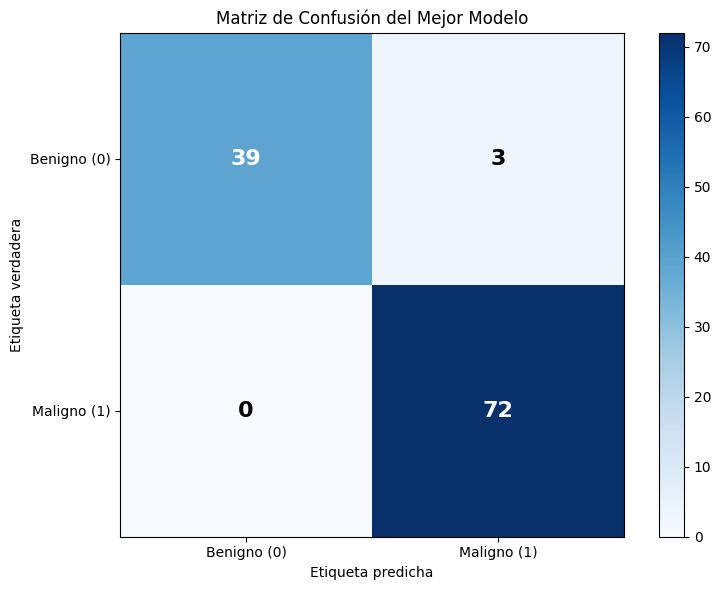

In [41]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)

print("\n=== MATRIZ DE CONFUSIÓN ===")
print(f"Verdaderos Negativos (TN):  {cm[0, 0]}  |  Falsos Positivos (FP): {cm[0, 1]}")
print(f"Falsos Negativos (FN):      {cm[1, 0]}  |  Verdaderos Positivos (TP): {cm[1, 1]}")

# Visualizar la matriz de confusión
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Etiquetas
classes = ['Benigno (0)', 'Maligno (1)']
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes,
       yticklabels=classes,
       ylabel='Etiqueta verdadera',
       xlabel='Etiqueta predicha',
       title='Matriz de Confusión del Mejor Modelo')

# Mostrar números en la matriz
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

fig.tight_layout()
plt.show()

### Análisis de errores

En este problema médico, el error más crítico es el **falso negativo (FN)**, ya que implica clasificar un tumor maligno como benigno, 
lo que podría retrasar el tratamiento crucial del paciente. Por ello, métricas como el **recall** son especialmente relevantes, 
ya que mide la capacidad del modelo de identificar correctamente los casos positivos (tumores malignos).

**Interpretación de la matriz de confusión del modelo seleccionado:**
- **Falsos Negativos (FN):** Número de tumores malignos incorrectamente clasificados como benignos (error crítico)
- **Recall (Sensibilidad):** Porcentaje de tumores malignos correctamente identificados
- **Precisión:** Confiabilidad de los diagnósticos positivos realizados por el modelo

## 8. Interpretación del modelo

Se analizan los resultados del modelo óptimo para comprender su toma de decisiones y el impacto de los hiperparámetros optimizados.

In [42]:
# Mostrar importancia de variables solo si el mejor modelo es Random Forest
if isinstance(best_model, type(grid_rf.best_estimator_)):
    print("\n=== IMPORTANCIA DE VARIABLES (Random Forest) ===")
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    
    print("\nTop 10 características más influyentes en la predicción:")
    print(importances.head(10))
    
    # Visualizar importancia de características
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.head(10).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Importancia')
    ax.set_ylabel('Característica')
    ax.set_title('Top 10 Características más Importantes (Random Forest)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nNota: El mejor modelo es {best_model_info}, que no proporciona importancia de características.")


Nota: El mejor modelo es kNN, que no proporciona importancia de características.


## Conclusiones

### Comparacion global de modelos

- Se comparan modelos de regresion (Lineal, Arbol de Decision, Random Forest) y de
  clasificacion (Regresion Logistica, kNN, Random Forest) con sus mejores ajustes.
- El rendimiento se evalua en el conjunto de prueba para comparar generalizacion.

### Tabla resumen de modelos

- La tabla siguiente muestra: modelo, mejores hiperparametros y metricas principales
  para ambos problemas.

### Justificacion de las metricas utilizadas

- **Regresion:** MAE mide el error absoluto promedio; RMSE penaliza mas los errores grandes;
  $R^2$ indica la proporcion de varianza explicada por el modelo.
- **Clasificacion:** Accuracy resume aciertos globales; Precision y Recall equilibran falsos
  positivos y falsos negativos; F1-score integra Precision y Recall. En el problema medico,
  el Recall es critico para minimizar falsos negativos.

### Sobreajuste, generalizacion y limitaciones

- Los arboles pueden sobreajustar si crecen demasiado; se controla con `max_depth`,
  `min_samples_leaf` y `min_samples_split` y se valida con `cv=5`.
- Random Forest reduce varianza al promediar muchos arboles, pero pierde interpretabilidad
  frente a modelos lineales.
- Los resultados dependen del dataset; no se realizo validacion externa ni analisis de
  drift, por lo que el rendimiento podria variar en datos futuros o de otra region.
- En clasificacion, el umbral de decision puede requerir ajuste segun el costo del error.

### Conclusiones generales del laboratorio

- La optimizacion de hiperparametros mejora el rendimiento y la estabilidad frente a
  modelos con parametros por defecto.
- En regresion, los modelos de ensamble capturan relaciones no lineales y logran mejores
  metricas que la regresion lineal.
- En clasificacion, la seleccion del modelo prioriza Recall para reducir falsos negativos
  en el contexto medico.
- Se recomienda evaluar con nuevos datos y validar en escenarios reales antes de usar en
  produccion.

In [44]:
# Tabla resumen con mejores hiperparametros y metricas
import unicodedata

summary_rows = []

def _normalize_series(series):
    return series.apply(
        lambda s: unicodedata.normalize("NFKD", s)
        .encode("ascii", "ignore")
        .decode("ascii")
        .lower()
    )

def _reg_row(key):
    names = _normalize_series(comparacion["Modelo"])
    idx = names[names.str.contains(key)].index[0]
    return comparacion.loc[idx]

def _reg_metrics(row):
    return f"MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f}, R2={row['R2']:.4f}"

summary_rows.append({
    "Problema": "Regresion",
    "Modelo": "Regresion Lineal",
    "Mejores hiperparametros": "default",
    "Metricas principales": _reg_metrics(_reg_row("lineal")),
})

summary_rows.append({
    "Problema": "Regresion",
    "Modelo": "Arbol de Decision",
    "Mejores hiperparametros": str(dt_gs.best_params_),
    "Metricas principales": _reg_metrics(_reg_row("arbol de decision")),
})

summary_rows.append({
    "Problema": "Regresion",
    "Modelo": "Random Forest",
    "Mejores hiperparametros": str(rf_rs.best_params_),
    "Metricas principales": _reg_metrics(_reg_row("random forest")),
})

def _clf_metrics(name):
    row = comparacion_optimizados.loc[name]
    return (
        f"Acc={row['Accuracy']:.4f}, Prec={row['Precision']:.4f}, "
        f"Recall={row['Recall']:.4f}, F1={row['F1-score']:.4f}"
    )

summary_rows.append({
    "Problema": "Clasificacion",
    "Modelo": "Regresion Logistica",
    "Mejores hiperparametros": str(grid_lr.best_params_),
    "Metricas principales": _clf_metrics("Logistic Regression (Opt)"),
})

summary_rows.append({
    "Problema": "Clasificacion",
    "Modelo": "kNN",
    "Mejores hiperparametros": str(grid_knn.best_params_),
    "Metricas principales": _clf_metrics("kNN (Opt)"),
})

summary_rows.append({
    "Problema": "Clasificacion",
    "Modelo": "Random Forest",
    "Mejores hiperparametros": str(grid_rf.best_params_),
    "Metricas principales": _clf_metrics("Random Forest (Opt)"),
})

tabla_resumen = pd.DataFrame(summary_rows)
tabla_resumen

,Problema,Modelo,Mejores hiperparametros,Metricas principales
0,Regresion,Regresion Lineal,default,"MAE=0.5332, RMSE=0.7456, R2=0.5758"
1,Regresion,Arbol de Decision,"{'max_depth': None, 'min_samples_leaf': 20, 'm...","MAE=0.4041, RMSE=0.5978, R2=0.7273"
2,Regresion,Random Forest,"{'n_estimators': 200, 'min_samples_leaf': 1, '...","MAE=0.3211, RMSE=0.4921, R2=0.8152"
3,Clasificacion,Regresion Logistica,"{'model__C': 0.1, 'model__solver': 'lbfgs'}","Acc=0.9737, Prec=0.9726, Recall=0.9861, F1=0.9793"
4,Clasificacion,kNN,"{'model__metric': 'euclidean', 'model__n_neigh...","Acc=0.9737, Prec=0.9600, Recall=1.0000, F1=0.9796"
5,Clasificacion,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...","Acc=0.9561, Prec=0.9589, Recall=0.9722, F1=0.9655"
